# Análise Exploratória Direto das Fontes Brutas
Neste notebook, vamos consumir os dados diretamente do **Banco de Dados (PIB)**, do **CSV (SCR)** e do **JSON bruto (IBGE)**, para gerar nossas análises focadas no Pará (PA). Nenhum dado intermediário foi utilizado.

In [11]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from sqlalchemy import create_engine
from dotenv import load_dotenv

# Estilos de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### 1. Carregando PIB direto do Banco de Dados (PostgreSQL)

In [12]:
# Conectando no Postgres
from dotenv import find_dotenv
load_dotenv(find_dotenv())

DB_HOST = os.getenv("DB_HOST", "localhost")
DB_NAME = os.getenv("DB_NAME", "projeto_cd")
DB_USER = os.getenv("DB_USER", "postgres")
DB_PASSWORD = os.getenv("DB_PASSWORD", "Tuavodecueca123@")
DB_PORT = os.getenv("DB_PORT", "5432")

import urllib.parse
encoded_password = urllib.parse.quote_plus(DB_PASSWORD)
engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{encoded_password}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

# Puxando apenas dados do Pará (uf = PA)
query = "SELECT codigo_municipio, nome_municipio, ano, pib_corrente_mil_reais FROM pib_municipal WHERE nome_municipio LIKE '%% - PA'"
df_pib = pd.read_sql(query, engine)

# Limpando o nome da cidade
df_pib['cidade'] = df_pib['nome_municipio'].str.split(' - ').str[0].str.strip().str.upper()
df_pib['pib_corrente_mil_reais'] = pd.to_numeric(df_pib['pib_corrente_mil_reais'], errors='coerce')

display(df_pib.head())

,codigo_municipio,nome_municipio,ano,pib_corrente_mil_reais,cidade
0,1500107,Abaetetuba - PA,37,2441092.0,ABAETETUBA
1,1500131,Abel Figueiredo - PA,37,131077.0,ABEL FIGUEIREDO
2,1500206,Acará - PA,37,2111467.0,ACARÁ
3,1500305,Afuá - PA,37,665557.0,AFUÁ
4,1500347,Água Azul do Norte - PA,37,1047226.0,ÁGUA AZUL DO NORTE


### 2. Carregando População direto do JSON bruto da API (Bronze)

In [13]:
# Pegando o JSON mais recente da pasta Bronze do IBGE
import os
from dotenv import find_dotenv
ROOT_DIR = os.path.dirname(find_dotenv())
ibge_dir = os.path.join(ROOT_DIR, 'data', 'bronze', 'ibge_populacao')
if os.path.exists(ibge_dir):
    json_files = sorted([f for f in os.listdir(ibge_dir) if f.endswith('.json')])
    if json_files:
        with open(os.path.join(ibge_dir, json_files[-1]), 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        df_ibge = pd.DataFrame(data[1:])
        df_ibge = df_ibge[['D1N', 'V']].rename(columns={'D1N': 'municipio_uf', 'V': 'populacao'})
        
        df_ibge = df_ibge[df_ibge['municipio_uf'].str.endswith(' - PA')].copy()
        df_ibge['cidade'] = df_ibge['municipio_uf'].str.split(' - ').str[0].str.strip().str.upper()
        df_ibge['populacao'] = pd.to_numeric(df_ibge['populacao'], errors='coerce')
        
        display(df_ibge.head())
    else:
        print("Nenhum arquivo JSON encontrado no IBGE.")
else:
    print("Pasta do IBGE não encontrada.")

,municipio_uf,populacao,cidade
151,Abaetetuba - PA,158188,ABAETETUBA
152,Abel Figueiredo - PA,6136,ABEL FIGUEIREDO
153,Acará - PA,59023,ACARÁ
154,Afuá - PA,37765,AFUÁ
155,Água Azul do Norte - PA,18080,ÁGUA AZUL DO NORTE


### 3. Cruzamento e Cálculo do PIB per capita (Apenas Pará)

/tmp/ipykernel_11923/1924136353.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_ricos, x='pib_per_capita', y='cidade', ax=axes[0], palette='viridis')
/tmp/ipykernel_11923/1924136353.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_pobres, x='pib_per_capita', y='cidade', ax=axes[1], palette='magma')


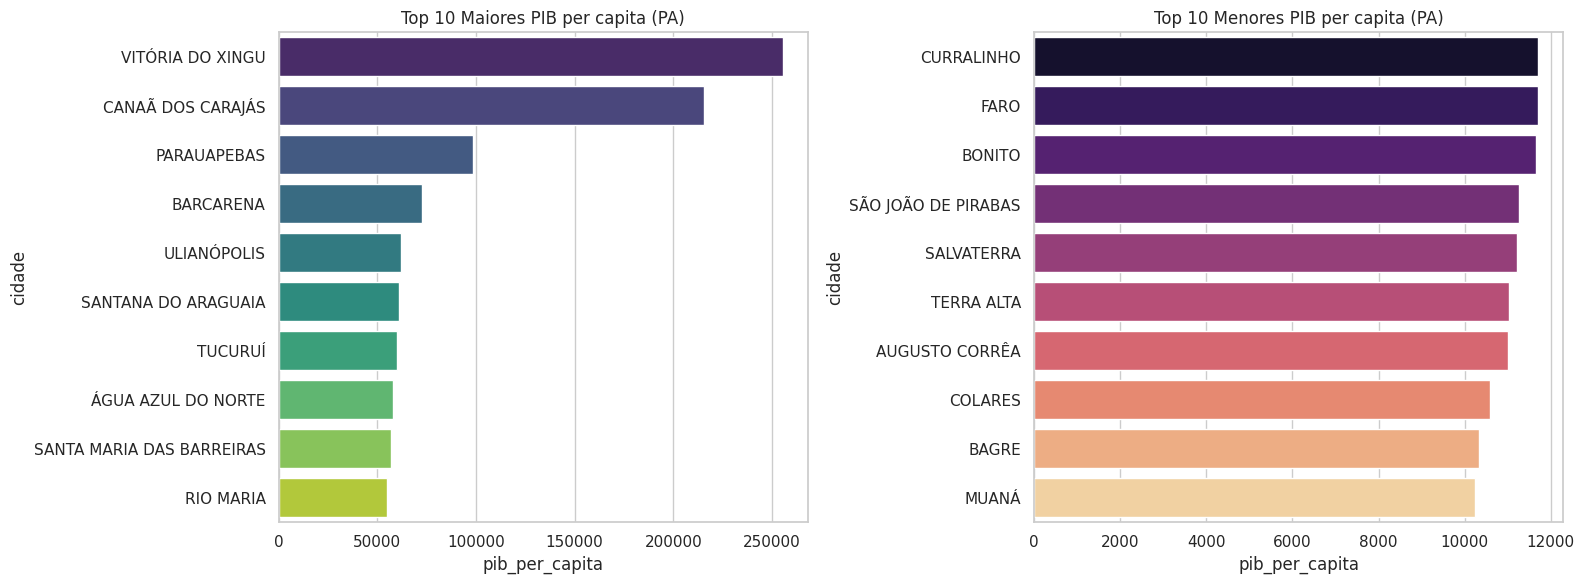

In [14]:
if 'df_pib' in locals() and 'df_ibge' in locals():
    df_cruzado = pd.merge(df_pib, df_ibge, on='cidade', how='inner')
    
    df_cruzado['pib_per_capita'] = (df_cruzado['pib_corrente_mil_reais'] * 1000) / df_cruzado['populacao']
    df_cruzado = df_cruzado.sort_values('pib_per_capita', ascending=False)
    
    top10_ricos = df_cruzado.head(10)
    top10_pobres = df_cruzado.tail(10)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.barplot(data=top10_ricos, x='pib_per_capita', y='cidade', ax=axes[0], palette='viridis')
    axes[0].set_title('Top 10 Maiores PIB per capita (PA)')
    
    sns.barplot(data=top10_pobres, x='pib_per_capita', y='cidade', ax=axes[1], palette='magma')
    axes[1].set_title('Top 10 Menores PIB per capita (PA)')
    
    plt.tight_layout()
    plt.show()

### 4. Carregando SCR direto do CSV gigante
Lendo o CSV bruto direto usando Polars Lazy para não travar a RAM.

In [15]:
csv_path = os.path.join(ROOT_DIR, 'csv', 'scrdata_completo.csv')

if os.path.exists(csv_path):
    # Execução preguiçosa
    q_scr = pl.scan_csv(csv_path, separator=";")
    q_pa = q_scr.filter(pl.col('uf') == 'PA')
    
    for col in ['carteira_ativa', 'carteira_inadimplencia']:
        q_pa = q_pa.with_columns(
            pl.col(col)
            .str.replace_all(r"\.", "")
            .str.replace(",", ".")
            .cast(pl.Float64, strict=False)
        )
        
    q_evolucao = (
        q_pa.filter(pl.col('carteira_ativa').is_not_null())
        .group_by('data_base')
        .agg([
            pl.col('carteira_ativa').sum().alias('total_carteira_ativa'),
            pl.col('carteira_inadimplencia').sum().alias('total_inadimplencia')
        ])
    )
    
    df_scr = q_evolucao.collect().to_pandas()
    
    if not df_scr.empty:
        df_scr['taxa_inadimplencia_perc'] = (df_scr['total_inadimplencia'] / df_scr['total_carteira_ativa']) * 100
        df_scr['data_base'] = pd.to_datetime(df_scr['data_base'])
        df_scr = df_scr.sort_values('data_base')
        
        plt.figure(figsize=(14, 5))
        sns.lineplot(data=df_scr, x='data_base', y='taxa_inadimplencia_perc', marker='o', color='red', linewidth=2)
        plt.title('Evolução da Taxa de Inadimplência de Crédito no Pará (PA)')
        plt.xlabel('Data')
        plt.ylabel('Inadimplência (%)')
        plt.show()
else:
    print("O arquivo CSV gigante não foi encontrado na pasta 'csv/'")

KeyboardInterrupt: 